In [2]:
import os 
import numpy as np
import pandas as pd 
from collections import defaultdict

#for Web scraper 
import selenium
import twilio
import pybettor 

#for kaggle data
import kaggle
import tempfile
from io import StringIO

#ml models
import xgboost  
import lightgbm

#metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#data handling
from sklearn.preprocessing import LabelEncoder 

#plotting
import seaborn as sns
import matplotlib.pyplot as plt

Sports Betting: nerual networks and portfolio theory, kelly criterion info 
- https://arxiv.org/abs/2307.13807?utm_source=chatgpt.com

Web Scraping and Kelly Criterion EV 
- https://github.com/jacksebastian17/betting-algo?utm_source=chatgpt.com

ML for NBA stratedgy 
- https://github.com/kyleskom/NBA-Machine-Learning-Sports-Betting

Sports odds history with csv files
- https://www.sportsoddshistory.com/?utm_source=chatgpt.com

Survey of Current Research 
- https://arxiv.org/pdf/2410.21484
- Calibration over accuracy, does the distribution of predicted outcomes match real world 
    - https://en.wikipedia.org/wiki/Brier_score

Reinforcement Based Approach
- https://ieeexplore.ieee.org/document/9969987?utm_source=chatgpt.com

Elo Rating Model 
- https://arxiv.org/pdf/1802.00527

Live UFC Betting Strategy
- https://arxiv.org/pdf/2312.11067


Data Sets to start off with 
NBA
-https://www.kaggle.com/datasets/pablote/nba-enhanced-stats
-https://www.kaggle.com/datasets/ehallmar/nba-historical-stats-and-betting-data?utm_source=chatgpt.com\

NFL
-https://www.kaggle.com/datasets/tobycrabtree/nfl-scores-and-betting-data?utm_source=chatgpt.com

Soccer
-https://www.kaggle.com/datasets/austro/beat-the-bookie-worldwide-football-dataset?utm_source=chatgpt.com
https://www.kaggle.com/datasets/eladsil/football-games-odds?utm_source=chatgpt.com

UFC
-https://www.kaggle.com/datasets/mdabbert/ultimate-ufc-dataset?utm_source=chatgpt.com
        - github repo: 
        - https://github.com/shortlikeafox/tiger-millionaire/wiki
- updated csv of aggregated kaggle ufc stats 
    -https://www.kaggle.com/datasets/aaronfriasr/ufc-fighters-statistics




In [3]:
#ufc aggregated library

def get_dataset(dataset_name):
    files = kaggle.api.dataset_list_files(dataset_name).files
    csv_file = files[0].name

    csv_data = kaggle.api.dataset_download_file(dataset_name, csv_file, quiet=False)
    with tempfile.TemporaryDirectory() as temp_dir:
        kaggle.api.dataset_download_files(dataset_name, path=temp_dir, unzip=True)
        
        # Construct full file path
        csv_path = os.path.join(temp_dir, csv_file)
        
        # Load the CSV file into Pandas DataFrame
        df = pd.read_csv(csv_path)

    return df
    


dataset = "mdabbert/ultimate-ufc-dataset"
ufc = get_dataset(dataset) 

Dataset URL: https://www.kaggle.com/datasets/mdabbert/ultimate-ufc-dataset
ufc-master.csv: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com/datasets/mdabbert/ultimate-ufc-dataset


In [4]:
def elo_rating(df,k):
    elo_dic = defaultdict()
    red_elo = []
    blue_elo = []
    for _, row in df.iterrows(): 
        red_name = row['RedFighter']
        blue_name = row['BlueFighter']
        if red_name not in elo_dic:
            elo_dic[red_name] = [1500]
        if blue_name not in elo_dic:
            elo_dic[blue_name] = [1500]
        if row['Winner'] == 'Red':
            prev_blue = elo_dic[blue_name][-1]
            prev_red = elo_dic[red_name][-1]
            red_elo.append(prev_red)
            blue_elo.append(prev_blue)

            d = prev_red - prev_blue
            mu = 1 / (1 + 10**(-d/400))
            red_new = prev_red + k * (1-mu) #red wins

            d = prev_blue - prev_red
            mu = 1 / (1 + 10**(-d/400))
            blue_new = prev_blue + k * (0-mu) #blue loses
            
            elo_dic[red_name].append(red_new)
            elo_dic[blue_name].append(blue_new)

        if row['Winner'] == 'Blue':
            prev_blue = elo_dic[blue_name][-1]
            prev_red = elo_dic[red_name][-1]
            red_elo.append(prev_red)
            blue_elo.append(prev_blue)

            d = prev_blue - prev_red
            mu = 1 / (1 + 10**(-d/400))
            blue_new = blue_new + k * (1-mu) #blue wins

            d = prev_red - prev_blue
            mu = 1 / (1 + 10**(-d/400))
            red_new = prev_red + k * (0-mu) #red loses
            
            elo_dic[red_name].append(red_new)
            elo_dic[blue_name].append(blue_new)

    return elo_dic, red_elo, blue_elo

elo_dic, red_elo,blue_elo = elo_rating(ufc, 15)
ufc['red_elo'] = red_elo
ufc['blue_elo'] = blue_elo

In [5]:
ufc.columns
for c in ufc.columns:
    print(c)

RedFighter
BlueFighter
RedOdds
BlueOdds
RedExpectedValue
BlueExpectedValue
Date
Location
Country
Winner
TitleBout
WeightClass
Gender
NumberOfRounds
BlueCurrentLoseStreak
BlueCurrentWinStreak
BlueDraws
BlueAvgSigStrLanded
BlueAvgSigStrPct
BlueAvgSubAtt
BlueAvgTDLanded
BlueAvgTDPct
BlueLongestWinStreak
BlueLosses
BlueTotalRoundsFought
BlueTotalTitleBouts
BlueWinsByDecisionMajority
BlueWinsByDecisionSplit
BlueWinsByDecisionUnanimous
BlueWinsByKO
BlueWinsBySubmission
BlueWinsByTKODoctorStoppage
BlueWins
BlueStance
BlueHeightCms
BlueReachCms
BlueWeightLbs
RedCurrentLoseStreak
RedCurrentWinStreak
RedDraws
RedAvgSigStrLanded
RedAvgSigStrPct
RedAvgSubAtt
RedAvgTDLanded
RedAvgTDPct
RedLongestWinStreak
RedLosses
RedTotalRoundsFought
RedTotalTitleBouts
RedWinsByDecisionMajority
RedWinsByDecisionSplit
RedWinsByDecisionUnanimous
RedWinsByKO
RedWinsBySubmission
RedWinsByTKODoctorStoppage
RedWins
RedStance
RedHeightCms
RedReachCms
RedWeightLbs
RedAge
BlueAge
LoseStreakDif
WinStreakDif
LongestWinStrea

In [7]:
np.unique(ufc['BPFPRank'])

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
       14., 15., nan])

In [9]:
#Predict Red or Blue winner with odds
#X_train.info()
ufc["ID"] = np.arange(len(ufc))

le = LabelEncoder()
ufc = ufc.sort_values(by="Date", ascending=True)

selected_features = ["Winner",
    'RedOdds', 'BlueOdds', 'RedLosses', 'BlueLosses', 'BlueLongestWinStreak', 'RedLongestWinStreak', 'Gender', 
    'KODif', 'SubDif', 'HeightDif', 'ReachDif', 'RedExpectedValue', 'BlueExpectedValue', 
    'BlueCurrentLoseStreak', 'BlueCurrentWinStreak', 'BlueDraws', 'BlueAvgSigStrLanded', 'BlueAvgSigStrPct', 
    'BlueAvgSubAtt', 'BlueAvgTDLanded', 'BlueAvgTDPct', 
    'BlueTotalRoundsFought', 'BlueTotalTitleBouts', 'BlueWinsByDecisionMajority', 'BlueWinsByDecisionSplit', 
    'BlueWinsByDecisionUnanimous', 'BlueWinsByKO', 'BlueWinsBySubmission', 'BlueWinsByTKODoctorStoppage', 
    'BlueWins', 'BlueHeightCms', 'BlueReachCms', 'BlueWeightLbs', 
    'RedCurrentLoseStreak', 'RedCurrentWinStreak', 'RedDraws', 'RedAvgSigStrLanded', 'RedAvgSigStrPct', 
    'RedAvgSubAtt', 'RedAvgTDLanded', 'RedAvgTDPct',
    'RedTotalRoundsFought', 'RedTotalTitleBouts', 'RedWinsByDecisionMajority', 'RedWinsByDecisionSplit', 
    'RedWinsByDecisionUnanimous', 'RedWinsByKO', 'RedWinsBySubmission', 'RedWinsByTKODoctorStoppage','AvgTDDif','SigStrDif','AgeDif','AvgSubAttDif','LoseStreakDif',
    'LongestWinStreakDif','TotalRoundDif', 'RedAge','BlueAge','NumberOfRounds','FinishDetails','Finish','WinDif','LossDif','TotalTitleBoutDif', 'WeightClass','BetterRank','RedStance','BlueStance',
    'Country', 'WinStreakDif', 'Location','red_elo','blue_elo','BPFPRank', 'RPFPRank',
    'Date',"RedFighter",'BlueFighter'
]

model_dat = ufc[selected_features]
model_dat['FinishDetails'] = le.fit_transform(model_dat['FinishDetails'])
model_dat['Finish'] = le.fit_transform(model_dat['Finish'])
model_dat['WeightClass'] = le.fit_transform(model_dat['WeightClass'])
model_dat['BetterRank'] = le.fit_transform(model_dat['BetterRank'])
model_dat['RedStance'] = le.fit_transform(model_dat['RedStance'])
model_dat['BlueStance'] = le.fit_transform(model_dat['BlueStance'])
model_dat['Country'] = le.fit_transform(model_dat['Country'])
model_dat['Location'] = le.fit_transform(model_dat['Location'])
model_dat['BPFPRank'] = model_dat['BPFPRank'].fillna(0)
model_dat['RPFPRank'] = model_dat['RPFPRank'].fillna(0)

train_dat = model_dat[:int(len(ufc)*0.8)]
test_dat = model_dat[int(len(ufc)*0.8):]
train_dat = train_dat.drop(columns=['Date',"RedFighter",'BlueFighter'])
train_dat['Gender'] = train_dat["Gender"].map({"MALE":1,"FEMALE":0}).astype(int)
train_dat["Winner"] = train_dat['Winner'].map({'Red':1,"Blue":0}).astype(int)
test_dat['Gender'] = test_dat["Gender"].map({"MALE":1,"FEMALE":0}).astype(int)
test_dat["Winner"] = test_dat['Winner'].map({'Red':1,"Blue":0}).astype(int)

train_dat = train_dat.dropna(axis=0)
test_dat = test_dat.dropna(axis=0)

X_train = train_dat.drop(columns=["Winner"])
y_train = train_dat['Winner']
X_test = test_dat[selected_features].drop(columns=["Winner","Date","RedFighter",'BlueFighter'])
y_test = test_dat["Winner"]

C:\Users\jcmar\AppData\Local\Temp\ipykernel_68764\3558778412.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_dat['FinishDetails'] = le.fit_transform(model_dat['FinishDetails'])
C:\Users\jcmar\AppData\Local\Temp\ipykernel_68764\3558778412.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_dat['Finish'] = le.fit_transform(model_dat['Finish'])
C:\Users\jcmar\AppData\Local\Temp\ipykernel_68764\3558778412.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a D

In [194]:
model_dat.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6528 entries, 6527 to 0
Data columns (total 74 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Winner                       6528 non-null   object 
 1   RedOdds                      6301 non-null   float64
 2   BlueOdds                     6302 non-null   float64
 3   RedLosses                    6528 non-null   int64  
 4   BlueLosses                   6528 non-null   int64  
 5   BlueLongestWinStreak         6528 non-null   int64  
 6   RedLongestWinStreak          6528 non-null   int64  
 7   Gender                       6528 non-null   object 
 8   KODif                        6528 non-null   int64  
 9   SubDif                       6528 non-null   int64  
 10  HeightDif                    6528 non-null   float64
 11  ReachDif                     6528 non-null   float64
 12  RedExpectedValue             6301 non-null   float64
 13  BlueExpectedValue      

In [21]:
xgb = xgboost.XGBClassifier(
    objective="binary:logistic", 
    eval_metric="logloss",  
    n_estimators = 1500,
    max_depth=6,
    learning_rate=.005,
    min_child_weight=1.5,
    reg_alpha=5,
    reg_lambda=5,
    gamma=1.5 # pruning 
)

X_train = np.array(X_train)
X_test = np.array(X_test)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
print(f'Accuracy: {accuracy}')
# xgboost.plot_importance(xgb)
probability_scores = xgb.predict_proba(X_test)

Accuracy: 0.711645101663586


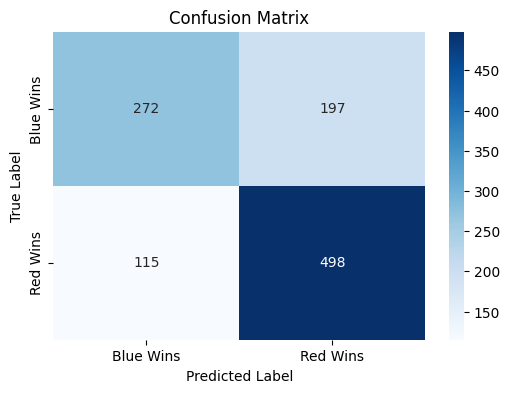

              precision    recall  f1-score   support

           0       0.70      0.58      0.64       469
           1       0.72      0.81      0.76       613

    accuracy                           0.71      1082
   macro avg       0.71      0.70      0.70      1082
weighted avg       0.71      0.71      0.71      1082



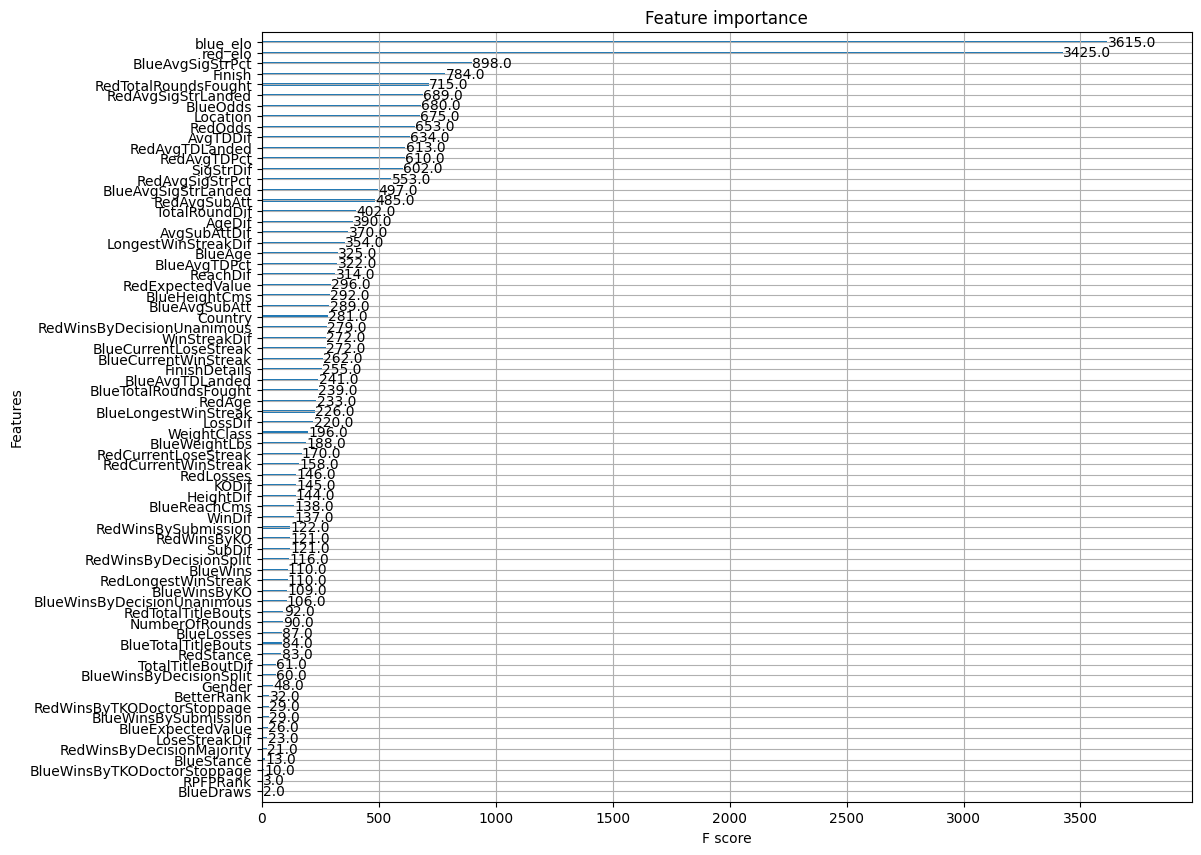

In [22]:
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Blue Wins", "Red Wins"], yticklabels=["Blue Wins", "Red Wins"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred))

drop_columns = ('Winner','Date','RedFighter','BlueFighter')
column_names = [c for c in selected_features if c not in drop_columns ]
xgb.get_booster().feature_names = column_names
fig, ax = plt.subplots(figsize=(12, 10))  # Force width=12, height=10

xgboost.plot_importance(xgb, ax=ax)  
plt.show()

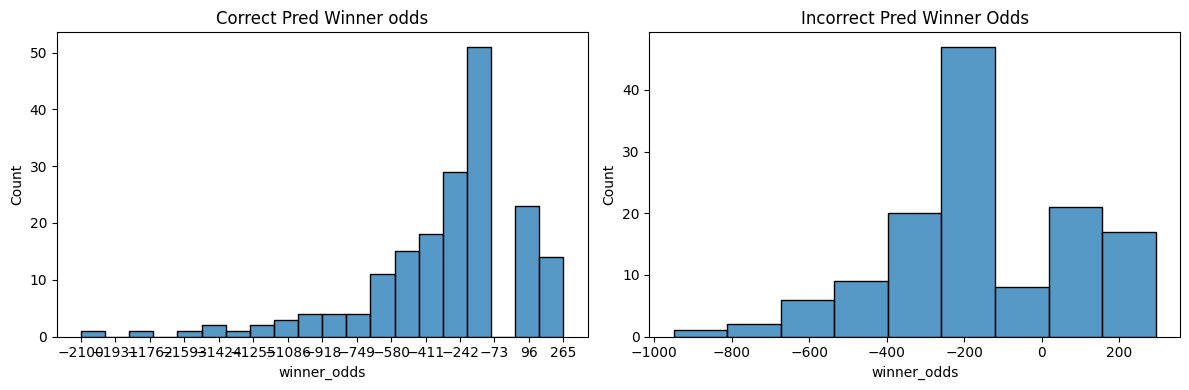

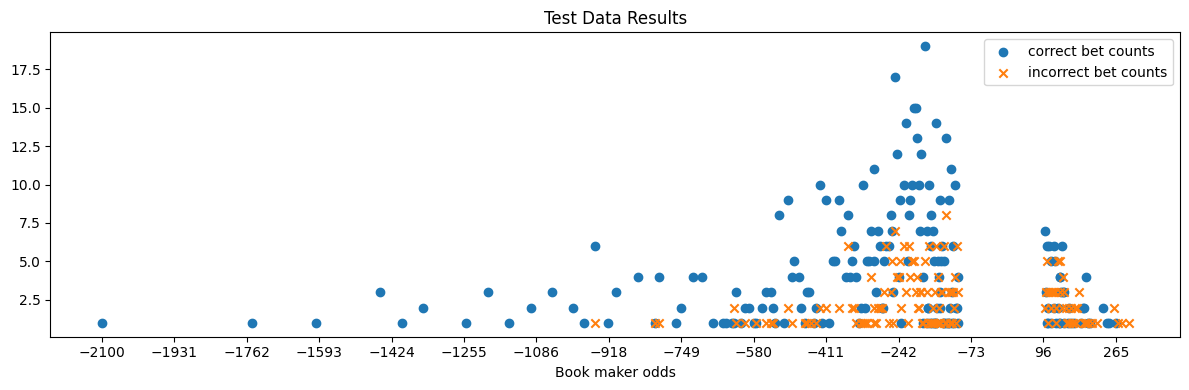

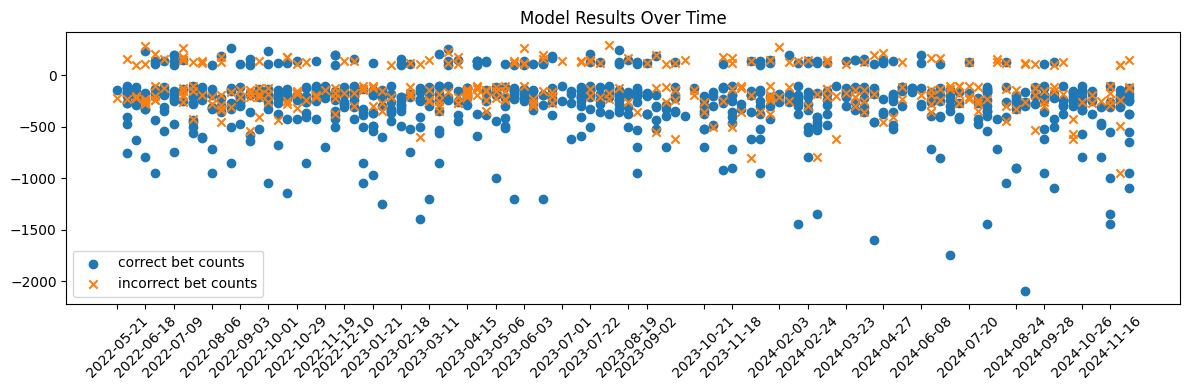

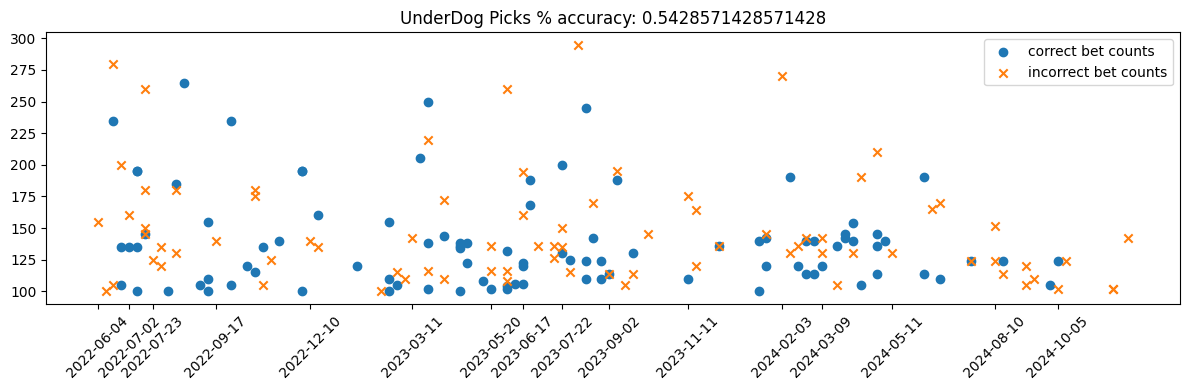

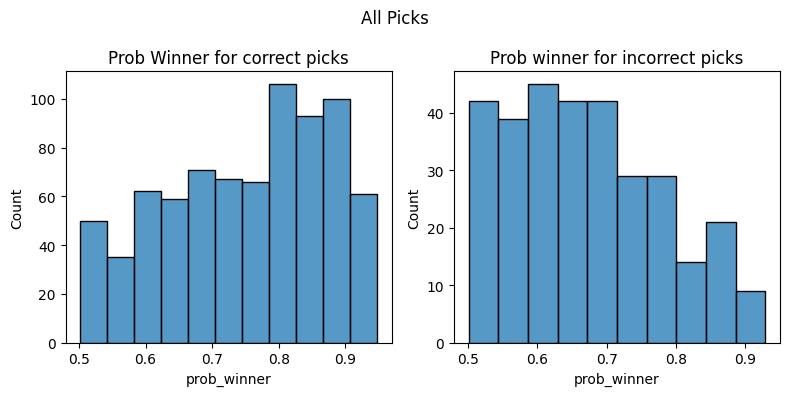

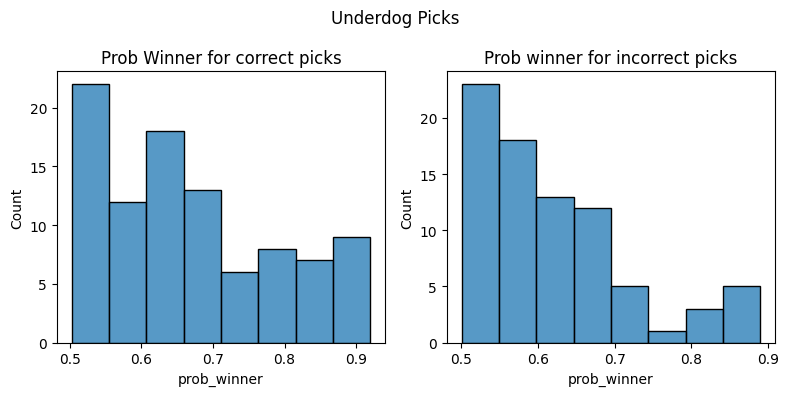

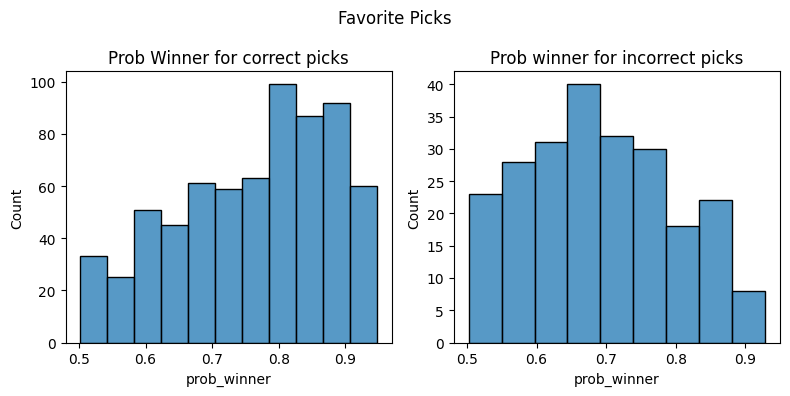

In [23]:
df_results = test_dat.copy()  # Avoid modifying the original test_dat
df_results['prob_blue_winner'] = probability_scores[:,0]
df_results['prob_red_winner'] = probability_scores[:,1]
df_results['prob_winner'] = df_results[['prob_blue_winner','prob_red_winner']].max(axis=1)
df_results['Date'] = test_dat['Date']
df_results['winner_odds'] = np.where(df_results['Winner'] == 1, df_results['RedOdds'], df_results['BlueOdds'])
df_results['pred_winner'] = y_pred
df_results['correct_pred_winner'] = (df_results['pred_winner'] == df_results['Winner']).astype(int)

# Filter correct predictions
df_correct_pred = df_results[df_results["correct_pred_winner"] == 1].copy() 
df_correct_pred['winner_odds'] = np.where(df_correct_pred['pred_winner'] == 1, df_correct_pred['RedOdds'], df_correct_pred['BlueOdds']) #pred_winner == 1 corresponds to red fighter 
pred_correct_odds = df_correct_pred['winner_odds'].value_counts().sort_index()

df_results['incorrect_pred_winner'] = (df_results['pred_winner'] != df_results['Winner']).astype(int)
df_incorrect_pred = df_results[df_results["incorrect_pred_winner"] == 1].copy()
df_incorrect_pred['winner_odds'] = np.where(df_incorrect_pred['pred_winner'] == 1, df_incorrect_pred['RedOdds'], df_incorrect_pred['BlueOdds'])
pred_incorrect_odds = df_incorrect_pred['winner_odds'].value_counts().sort_index()

#correct results over time 


# Plot the data
fig, axes = plt.subplots(1,2,figsize=(12, 4))
sns.histplot(pred_correct_odds.index, ax=axes[0])
axes[0].set_xticks(np.linspace(min(pred_correct_odds.index), max(pred_correct_odds.index), num=15))
axes[0].set_title("Correct Pred Winner odds")
sns.histplot(pred_incorrect_odds.index, ax=axes[1])
axes[1].set_title("Incorrect Pred Winner Odds")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
plt.scatter(pred_correct_odds.index, pred_correct_odds.values, marker='o', label='correct bet counts')
plt.scatter(pred_incorrect_odds.index, pred_incorrect_odds.values, marker='x', label='incorrect bet counts')
plt.xlabel("Book maker odds")
plt.xticks(np.linspace(min(pred_correct_odds.index), max(pred_correct_odds.index), num=15))
plt.title("Test Data Results")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(12,4))
plt.scatter(df_correct_pred["Date"], df_correct_pred['winner_odds'], marker='o', label='correct bet counts')
plt.scatter(df_incorrect_pred['Date'], df_incorrect_pred['winner_odds'], marker='x', label='incorrect bet counts')
plt.xticks(df_correct_pred["Date"][::25], rotation=45)
plt.legend()
plt.title("Model Results Over Time")
plt.tight_layout()
plt.show()

df_correct_underdog = df_correct_pred.loc[df_correct_pred['winner_odds'] > 0, ['winner_odds','Date','prob_winner','correct_pred_winner']]
df_incorrect_underdog = df_incorrect_pred.loc[df_incorrect_pred['winner_odds'] > 0, ['winner_odds','Date','prob_winner','correct_pred_winner']]
df_correct_underdog["Date"] = pd.to_datetime(df_correct_underdog["Date"])
df_incorrect_underdog["Date"] = pd.to_datetime(df_incorrect_underdog["Date"])
plt.figure(figsize=(12,4))
plt.scatter(df_correct_underdog["Date"], df_correct_underdog['winner_odds'], marker='o', label='correct bet counts')
plt.scatter(df_incorrect_underdog['Date'], df_incorrect_underdog['winner_odds'], marker='x', label='incorrect bet counts')
plt.xticks(df_incorrect_underdog["Date"][::5], rotation=45)
plt.legend()
plt.title(f"UnderDog Picks % accuracy: {len(df_correct_underdog)/ (len(df_correct_underdog)+len(df_incorrect_underdog))}")
plt.tight_layout()
plt.show()

df_correct_pred['prob_winner'] = df_correct_pred[['prob_blue_winner','prob_red_winner']].max(axis=1)
df_incorrect_pred['prob_winner'] = df_incorrect_pred[['prob_blue_winner','prob_red_winner']].max(axis=1)
fig, axes = plt.subplots(1,2, figsize=(8,4))
sns.histplot(df_correct_pred['prob_winner'], ax=axes[0])
axes[0].set_title('Prob Winner for correct picks')
sns.histplot(df_incorrect_pred['prob_winner'], ax=axes[1])
axes[1].set_title('Prob winner for incorrect picks')
fig.suptitle('All Picks')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1,2, figsize=(8,4))
sns.histplot(df_correct_underdog['prob_winner'], ax=axes[0])
axes[0].set_title('Prob Winner for correct picks')
sns.histplot(df_incorrect_underdog['prob_winner'], ax=axes[1])
axes[1].set_title('Prob winner for incorrect picks')
fig.suptitle('Underdog Picks')
plt.tight_layout()
plt.show()

correct_fav = df_correct_pred.loc[df_correct_pred['winner_odds'] < 0, ['winner_odds','Date','prob_winner','correct_pred_winner']]
incorrect_fav = df_incorrect_pred.loc[df_incorrect_pred['winner_odds'] < 0, ['winner_odds','Date','prob_winner','correct_pred_winner']]
fig, axes = plt.subplots(1,2, figsize=(8,4))
sns.histplot(correct_fav['prob_winner'], ax=axes[0])
axes[0].set_title('Prob Winner for correct picks')
sns.histplot(incorrect_fav['prob_winner'], ax=axes[1])
axes[1].set_title('Prob winner for incorrect picks')
fig.suptitle('Favorite Picks')
plt.tight_layout()
plt.show()


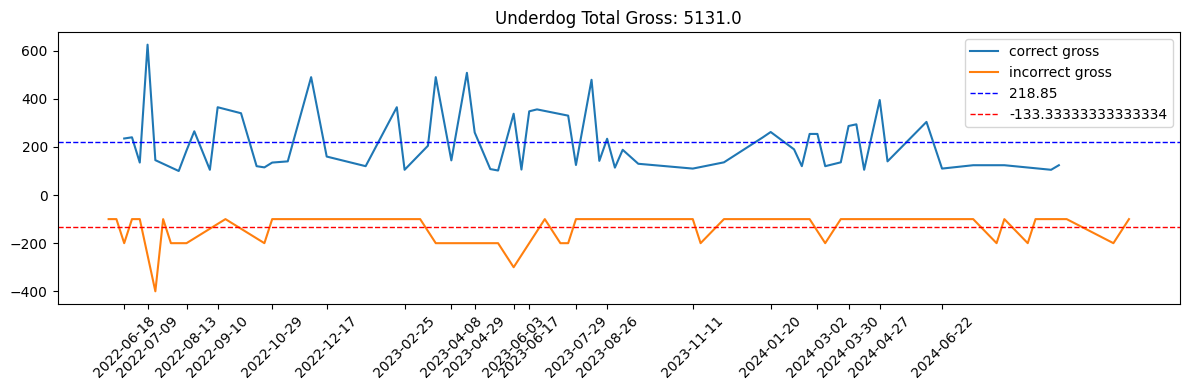

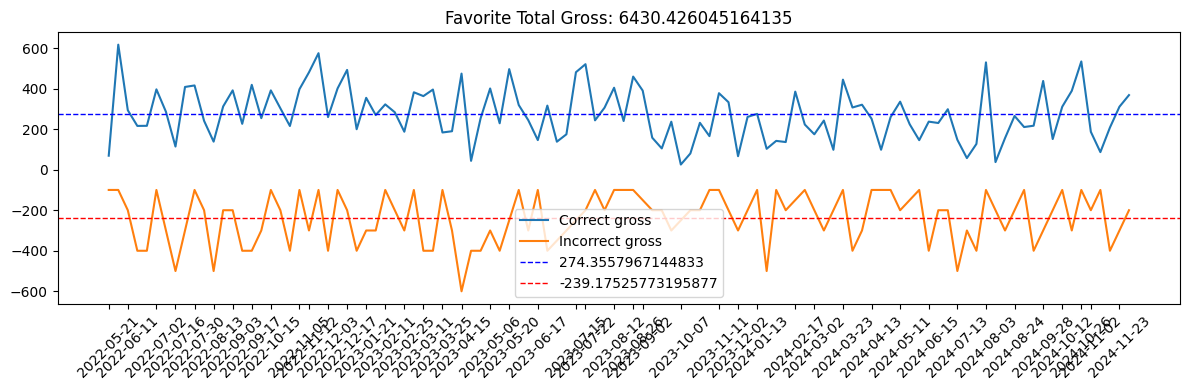

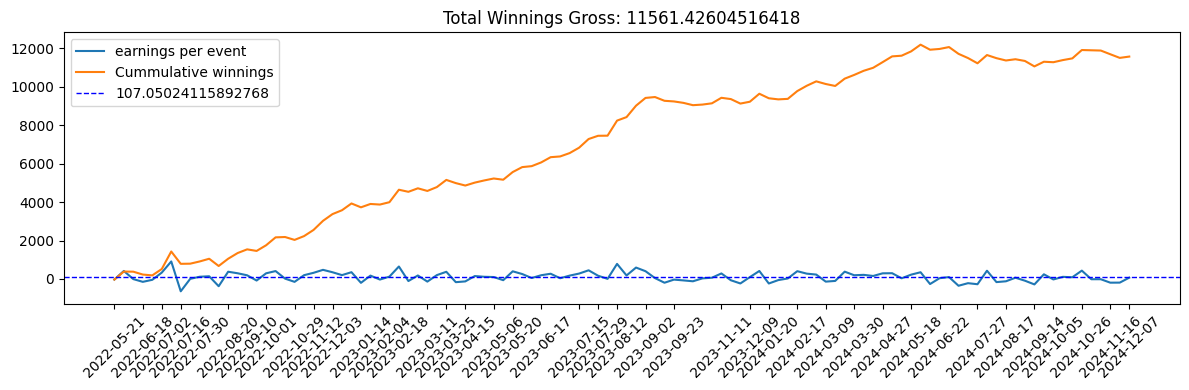

dog per bet: 29.32, fav per bet: 7.089775132485264


In [24]:
def expected_winnings(wager, odds, prob_w):
    ev = 0
    if odds > 0:
        ev = prob_w * ((odds/100) * wager) + (1-prob_w) * wager
    else: 
        ev = prob_w * ((100/odds) * wager) + (1-prob_w) * wager
    return ev

def winnings(wager, odds, win):
    gross = 0
    if win: 
        if odds > 0:
            gross = (odds/100) * wager
        else:
            gross = (100/-odds) * wager
    else:
        gross = -wager
    return gross 

def gross_winnings(df, wager):
    total_winnings = []
    for _,row in df.iterrows():
        line = row['winner_odds']
        win = None
        if row['correct_pred_winner'] == 1:
            win = True
        else:
            win = False
        gross = winnings(wager, line, win)
        total_winnings.append(gross)
    return total_winnings

wager = 100
df_correct_underdog['correct_underdog_winnings'] = gross_winnings(df_correct_underdog, wager)
df_incorrect_underdog['incorrect_underdog_loss'] = gross_winnings(df_incorrect_underdog, wager)
underdog_bet_gross = sum(df_correct_underdog['correct_underdog_winnings']) + sum(df_incorrect_underdog['incorrect_underdog_loss']
)
correct_fav['correct_fav_winnings'] = gross_winnings(correct_fav,wager)
incorrect_fav['incorrect_fav_loss'] = gross_winnings(incorrect_fav, wager)
total_fav_gross = sum(correct_fav['correct_fav_winnings']) + sum(incorrect_fav['incorrect_fav_loss'])

df_results['total_winnings'] = gross_winnings(df_results, wager)
total_gross = sum(df_results['total_winnings'])

group_correct = df_correct_underdog.groupby('Date')['correct_underdog_winnings'].sum()
group_incorrect = df_incorrect_underdog.groupby('Date')['incorrect_underdog_loss'].sum()
plt.figure(figsize=(12,4))
plt.plot(group_correct.index, group_correct.values, label='correct gross')
plt.plot(group_incorrect.index, group_incorrect.values, label='incorrect gross')
plt.xticks(df_correct_underdog["Date"][::5], rotation=45)
plt.axhline(y=np.mean(group_correct.values), color="blue", linestyle="--", linewidth=1, label=np.mean(group_correct.values))
plt.axhline(y=np.mean(group_incorrect.values), color="red", linestyle="--", linewidth=1, label=np.mean(group_incorrect.values))
plt.title(f"Underdog Total Gross: {underdog_bet_gross}")
plt.legend()
plt.tight_layout()
plt.show()

group_correct = correct_fav.groupby('Date')['correct_fav_winnings'].sum()
group_incorrect = incorrect_fav.groupby('Date')['incorrect_fav_loss'].sum()
plt.figure(figsize=(12,4))
plt.plot(group_correct.index, group_correct.values, label="Correct gross")
plt.plot(group_incorrect.index, group_incorrect.values, label="Incorrect gross")
plt.xticks(correct_fav["Date"][::15], rotation=45)
plt.axhline(y=np.mean(group_correct.values), color="blue", linestyle="--", linewidth=1, label=np.mean(group_correct.values))
plt.axhline(y=np.mean(group_incorrect.values), color="red", linestyle="--", linewidth=1, label=np.mean(group_incorrect.values))
plt.title(f'Favorite Total Gross: {total_fav_gross}')
plt.legend()
plt.tight_layout()
plt.show()

group_correct = df_results.groupby('Date')['total_winnings'].sum()
cum_winnings = np.cumsum(group_correct.values)
plt.figure(figsize=(12,4))
plt.plot(group_correct.index,group_correct.values, label='earnings per event')
plt.plot(group_correct.index, cum_winnings, label = 'Cummulative winnings')
plt.title(f'Total Winnings Gross: {total_gross}')
plt.xticks(df_results["Date"][::27], rotation=45)
plt.axhline(y=np.mean(group_correct.values), color="blue", linestyle="--", linewidth=1, label=np.mean(group_correct.values))
plt.legend()
plt.tight_layout()
plt.show()

dog_per_bet_gross = underdog_bet_gross / (len(df_correct_underdog)+len(df_incorrect_underdog))
fav_per_bet_gross = total_fav_gross / (len(correct_fav)+len(incorrect_fav))
print(f'dog per bet: {dog_per_bet_gross}, fav per bet: {fav_per_bet_gross}')


In [25]:
def winnings(wager, odds, win):
    gross = 0
    if win: 
        if odds > 0:
            gross = (odds/100) * wager
        else:
            gross = (100/-odds) * wager
    else:
        gross = -wager
    return gross 

C:\Users\jcmar\AppData\Local\Temp\ipykernel_68764\256164563.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_results['f_star'] = df_results.groupby('Date').apply(lambda group: group.apply(kelly_criterion, axis=1)).reset_index(level=0, drop=True)
C:\Users\jcmar\AppData\Local\Temp\ipykernel_68764\256164563.py:69: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_results.groupby('Date').apply(simulate_be

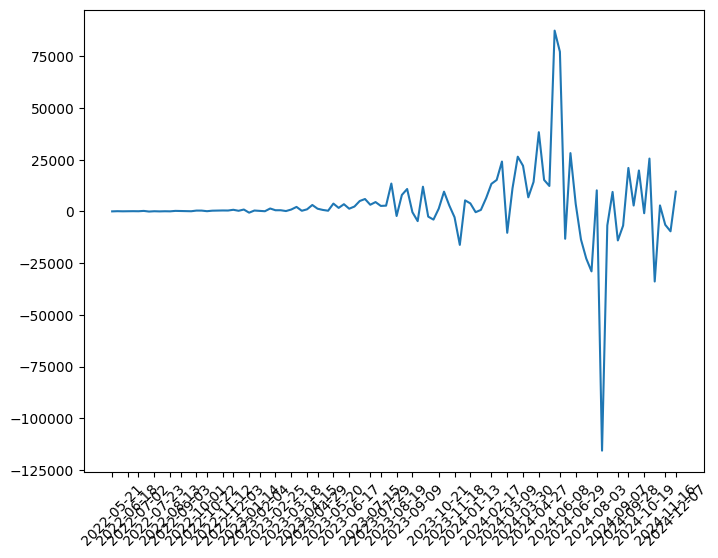

In [ ]:
def kelly_criterion(row):
    p = row['prob_winner']
    odds=0
    if row['pred_winner'] == 1:
        line = row['RedOdds']
        if line > 0: 
            odds = line/100
        else:
            odds = 100/-line
    else:
        line = row['BlueOdds']
        if line > 0: 
            odds = line/100
        else:
            odds = 100/-line
    f_star = p - ((1-p)/odds)
    return f_star

df_results['f_star'] = df_results.groupby('Date').apply(lambda group: group.apply(kelly_criterion, axis=1)).reset_index(level=0, drop=True)

df_results['group_size'] = df_results.groupby('Date')['Date'].transform('count')  # Get group size for each row
df_results['f_star'] = df_results['f_star'] / df_results['group_size']


initial_bankroll = 500
bankroll = initial_bankroll
bankroll_history = []  
wagers = []
single_payout = []
date_payout = defaultdict()

def simulate_betting(df):
    global bankroll, wagers, single_payout
    event_total = 0 
    date = df['Date'].iloc[0]
    for index, row in df.iterrows():
        
        bet_fraction = row['f_star'] 
        if bet_fraction < 0:
            payout = 0
            single_payout.append(payout)
            wagers.append(payout)
            continue  
        bet_size = bankroll * bet_fraction  
        wagers.append(bet_size)

        odds=0
        if row['pred_winner'] == row['Winner']:  
            if row['pred_winner'] == 1:
                odds = row['RedOdds']
            else:
                odds = row['BlueOdds']

            if odds > 0:
                payout = bet_size * (odds / 100)
                single_payout.append(payout)
            else:
                payout = bet_size * (100 / -odds)
                single_payout.append(payout)

            event_total += payout  
        else:
            event_total -= bet_size 
            single_payout.append(-bet_size) 

    date_payout[date] = payout
    bankroll_history.append(bankroll + event_total)
    bankroll = bankroll_history[-1]

df_results.groupby('Date').apply(simulate_betting)
df_results['single_payout'] = single_payout
df_results['event_payout'] = df_results.groupby('Date')['single_payout'].transform('sum')
# df_results['Payout'] = df_results['Date'].map(date_payout)
plt.figure(figsize=(8,6))
plt.plot(df_results['Date'], df_results['event_payout'])
plt.xticks(df_results["Date"][::30], rotation=45)
plt.show()
# [::27]

In [27]:
df_results[df_results['event_payout']<-200000]['Date']

Series([], Name: Date, dtype: object)

In [40]:
len(df_results)

1082

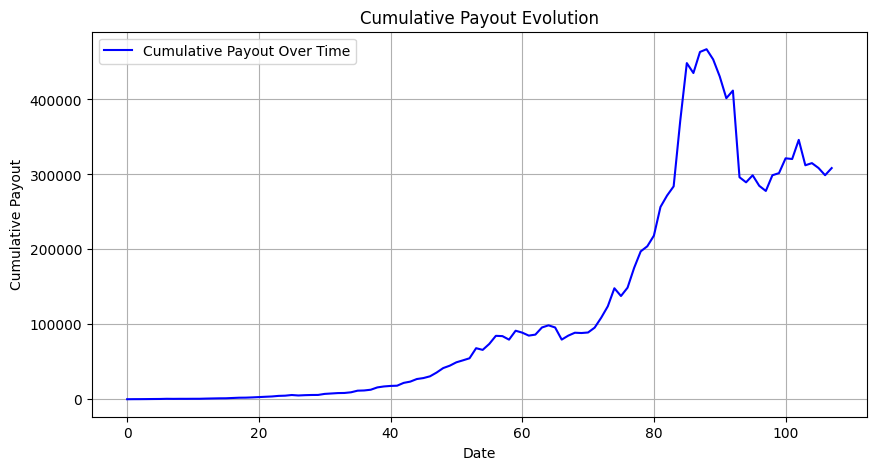

: 

In [ ]:
daily_payouts = df_results.groupby('Date')['event_payout'].first()  # Gets one value per date

cumulative_payouts = daily_payouts.cumsum()
payout_arr = np.array(cumulative_payouts.values)
plt.figure(figsize=(10,5))
plt.plot(payout_arr , label="Cumulative Payout Over Time", color="blue")

plt.xlabel("Date")
plt.ylabel("Cumulative Payout")
plt.title("Cumulative Payout Evolution")
plt.legend()
# plt.xticks(cumulative_payouts.index[::15], rotation=45)  # Show every 30th date for readability
plt.grid()

In [ ]:
print(577*.06, 577*.01, 577*.01, 577*.06, 577*.05, 577*.04, 577*.04, 577*.04, 577*.008, 577*.05, 577*.04 )

34.62 5.7700000000000005 5.7700000000000005 34.62 28.85 23.080000000000002 23.080000000000002 23.080000000000002 4.616 28.85 23.080000000000002


In [33]:
len(single_payout)
len(np.unique(df_results['Date']))

108

In [ ]:
df_results[['f_star','Date','pred_winner' , 'Winner',"RedOdds",'BlueOdds','f_star','wager','single_payout','event_payout','RedFighter','BlueFighter']].tail(50)``

,f_star,Date,pred_winner,Winner,RedOdds,BlueOdds,f_star,wager,single_payout,event_payout,RedFighter,BlueFighter
70,-0.009224,2024-10-26,0,1,215.0,-265.0,-0.009224,0.000000,0.000000,45496.977374,Mateusz Rebecki,Myktybek Orolbai
71,-0.002802,2024-10-26,1,1,-155.0,130.0,-0.002802,0.000000,0.000000,45496.977374,Abus Magomedov,Brunno Ferreira
53,-0.001098,2024-11-02,0,0,190.0,-250.0,-0.001098,0.000000,0.000000,-79428.161112,Ariane da Silva,Jasmine Jasudavicius
51,-0.020750,2024-11-02,1,1,-155.0,130.0,-0.020750,0.000000,0.000000,-79428.161112,Erin Blanchfield,Rose Namajunas
50,-0.020591,2024-11-02,1,1,-180.0,150.0,-0.020591,0.000000,0.000000,-79428.161112,Brandon Moreno,Amir Albazi
52,0.092558,2024-11-02,1,0,-192.0,160.0,0.092558,50992.095190,-50992.095190,-79428.161112,Caio Machado,Brendson Ribeiro
55,0.076050,2024-11-02,1,1,-375.0,295.0,0.076050,41897.329259,11172.621136,-79428.161112,Mike Malott,Trevin Giles
54,0.071896,2024-11-02,1,0,-270.0,220.0,0.071896,39608.687058,-39608.687058,-79428.161112,Marc-Andre Barriault,Dustin Stoltzfus
39,-0.152167,2024-11-09,0,0,550.0,-800.0,-0.152167,0.000000,0.000000,10325.915109,Neil Magny,Carlos Prates
40,-0.201224,2024-11-09,0,0,250.0,-310.0,-0.201224,0.000000,0.000000,10325.915109,Gerald Meerschaert,Reinier de Ridder


In [70]:
df_results.to_csv(r'C:\Users\jcmar\Documents\ufc_results.csv', index=False)


Latest UFC data from R : 
- https://tamaszilagyi.com/ufc.stats/ 

In [1]:
import pyreadr

In [ ]:
rda_file = r'C:\Users\jcmar\OneDrive\Vscode files\Sports_Betting\ufc_stats.rda'
result = pyreadr.read_r(rda_file)

# Extract the loaded objects (it returns a dictionary)
for key in result.keys():
    print(f"Object name: {key}")
    data = result[key]  # This is usually a pandas DataFrame
    print(data.head()) 

df = result['ufc_stats']
df.head()

Object name: ufc_stats
             fighter  knockdowns  significant_strikes_landed  \
0    Jared Cannonier           0                          22   
1  Gregory Rodrigues           2                          25   
2    Jared Cannonier           0                          33   
3  Gregory Rodrigues           0                          25   
4    Jared Cannonier           1                          34   

   significant_strikes_attempted  significant_strikes_rate  \
0                             38                      0.57   
1                             66                      0.37   
2                             72                      0.45   
3                             68                      0.36   
4                             78                      0.43   

   total_strikes_landed  total_strikes_attempted  takedown_successful  \
0                    31                       49                    1   
1                    26                       68                    0   


c:\Users\jcmar\OneDrive\Vscode files\Sports_Betting\venv\Lib\site-packages\pyreadr\_pyreadr_parser.py:233: RuntimeWarning: invalid value encountered in cast
  df[colname] = df[colname].values.astype("datetime64[D]").astype(datetime)


In [6]:
df = result['ufc_stats']
df.head()

,fighter,knockdowns,significant_strikes_landed,significant_strikes_attempted,significant_strikes_rate,total_strikes_landed,total_strikes_attempted,takedown_successful,takedown_attempted,takedown_rate,...,last_round,time,scheduled_rounds,winner,weight_class,event,fight_date,location,attendance,id
0,Jared Cannonier,0,22,38,0.57,31,49,1,1,1.0,...,4,0:21,5 Rnd (5-5-5-5-5),W,Middleweight Bout,UFC Fight Night: Cannonier vs. Rodrigues,2025-02-15,"Las Vegas, Nevada, USA",NaN,7989
1,Gregory Rodrigues,2,25,66,0.37,26,68,0,1,0.0,...,4,0:21,5 Rnd (5-5-5-5-5),L,Middleweight Bout,UFC Fight Night: Cannonier vs. Rodrigues,2025-02-15,"Las Vegas, Nevada, USA",NaN,7989
2,Jared Cannonier,0,33,72,0.45,35,74,0,1,0.0,...,4,0:21,5 Rnd (5-5-5-5-5),W,Middleweight Bout,UFC Fight Night: Cannonier vs. Rodrigues,2025-02-15,"Las Vegas, Nevada, USA",NaN,7989
3,Gregory Rodrigues,0,25,68,0.36,26,70,0,0,0.0,...,4,0:21,5 Rnd (5-5-5-5-5),L,Middleweight Bout,UFC Fight Night: Cannonier vs. Rodrigues,2025-02-15,"Las Vegas, Nevada, USA",NaN,7989
4,Jared Cannonier,1,34,78,0.43,34,79,0,1,0.0,...,4,0:21,5 Rnd (5-5-5-5-5),W,Middleweight Bout,UFC Fight Night: Cannonier vs. Rodrigues,2025-02-15,"Las Vegas, Nevada, USA",NaN,7989


In [7]:
df.columns

Index(['fighter', 'knockdowns', 'significant_strikes_landed',
       'significant_strikes_attempted', 'significant_strikes_rate',
       'total_strikes_landed', 'total_strikes_attempted',
       'takedown_successful', 'takedown_attempted', 'takedown_rate',
       'submission_attempt', 'reversals', 'head_landed', 'head_attempted',
       'body_landed', 'body_attempted', 'leg_landed', 'leg_attempted',
       'distance_landed', 'distance_attempted', 'clinch_landed',
       'clinch_attempted', 'ground_landed', 'ground_attempted', 'round',
       'result', 'last_round', 'time', 'scheduled_rounds', 'winner',
       'weight_class', 'event', 'fight_date', 'location', 'attendance', 'id'],
      dtype='object')